# N-body Simulation and Lightcone Generation

This notebook demonstrates running N-body simulations with lightcone generation. Key features:

1. Generate Gaussian initial conditions
2. Compute LPT displacements and momenta at initial scale factor
3. Run N-body simulation with different geometry options:
   - `geometry=None`: Save 3D density fields (flexible but memory-intensive)
   - `geometry="flat"`: Compute flat-sky projections on-the-fly (memory-efficient)
   - `geometry="spherical"`: Compute HEALPix projections on-the-fly (memory-efficient)
4. Post-hoc painting of saved density fields to different projections

## Setup and Imports

In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
import jax_cosmo as jc

from fwd_model_tools.field import FieldStatus, ParticleField, DensityField, FlatDensity, SphericalDensity
from fwd_model_tools.normal import gaussian_initial_conditions
from fwd_model_tools.pm import lpt, nbody
from fwd_model_tools.lensing_model import Planck18

/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


## Configuration

Set up simulation parameters. Using small mesh size for demonstration.

In [2]:
# Simulation parameters
mesh_size = (256, 256, 256)
box_size = (1000.0, 1000.0, 1000.0)  # in Mpc/h
observer_position = (0.5, 0.5, 0.5)
nside = 256
flatsky_npix = (256, 256)

# N-body parameters
t0 = 0.1  # Initial scale factor
t1 = 1.0  # Final scale factor (present day)
dt0 = 0.05  # Time step

# Random seed
key = jax.random.PRNGKey(42)
cosmo = Planck18()

print(f"Mesh size: {mesh_size}")
print(f"Box size: {box_size} Mpc/h")

Mesh size: (256, 256, 256)
Box size: (1000.0, 1000.0, 1000.0) Mpc/h


## Generate Initial Conditions

Create Gaussian initial conditions with the specified parameters.

In [3]:
gaussian_field = gaussian_initial_conditions(
    key=key,
    cosmo=cosmo,
    mesh_size=mesh_size,
    box_size=box_size,
    observer_position=observer_position,
    nside=nside,
    flatsky_npix=flatsky_npix,
)
gaussian_field = gaussian_field.replace(nb_shells=6)

print(f"Initial field: {gaussian_field}")
print(f"Status: {gaussian_field.status}")

Initial field: DensityField(array=Array(256, 256, 256), mesh_size=(256, 256, 256), box_size=(1000.0, 1000.0, 1000.0), status=initial_field, scale_factor_shape=(1,))
Status: FieldStatus.INITIAL_FIELD


## Compute LPT Initial Conditions

Compute LPT displacements and momenta at the initial scale factor `t0`.

In [4]:
dx_field, p_field = lpt(cosmo, gaussian_field, a=t0, order=1)

print(f"Displacement field: {dx_field}")
print(f"Array shape: {dx_field.array.shape}")
print(f"Scale factor: {dx_field.scale_factor}")

# Compute number of shells from field properties
max_radius = dx_field.max_comoving_radius
density_plane_width = dx_field.density_width
nb_shells = int(max_radius // float(density_plane_width))
print(f"Number of shells: {nb_shells}")

shape of initial force: (256, 256, 256, 3)
growth factor shape: (1,)
Displacement field: ParticleField(array=Array(256, 256, 256, 3), mesh_size=(256, 256, 256), box_size=(1000.0, 1000.0, 1000.0), status=lpt1, scale_factor_shape=(1,))
Array shape: (256, 256, 256, 3)
Scale factor: [0.1]
Number of shells: 6


## Run N-body with geometry=None

Run N-body simulation saving 3D density fields at each shell. This is flexible (can paint to any projection later) but memory-intensive.

In [5]:
# Run N-body with geometry=None to save 3D density fields
density_snapshots = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=t1,
    dt0=dt0,
    geometry='particles',
)

print(f"Density snapshots: {density_snapshots}")
print(f"Array shape: {density_snapshots.array.shape}")
print(f"Scale factor shape: {density_snapshots.scale_factor.shape}")

Density snapshots: ParticleField(array=Array(6, 256, 256, 256, 3), mesh_size=(256, 256, 256), box_size=(1000.0, 1000.0, 1000.0), status=lpt1, scale_factor_shape=(6,))
Array shape: (6, 256, 256, 256, 3)
Scale factor shape: (6,)


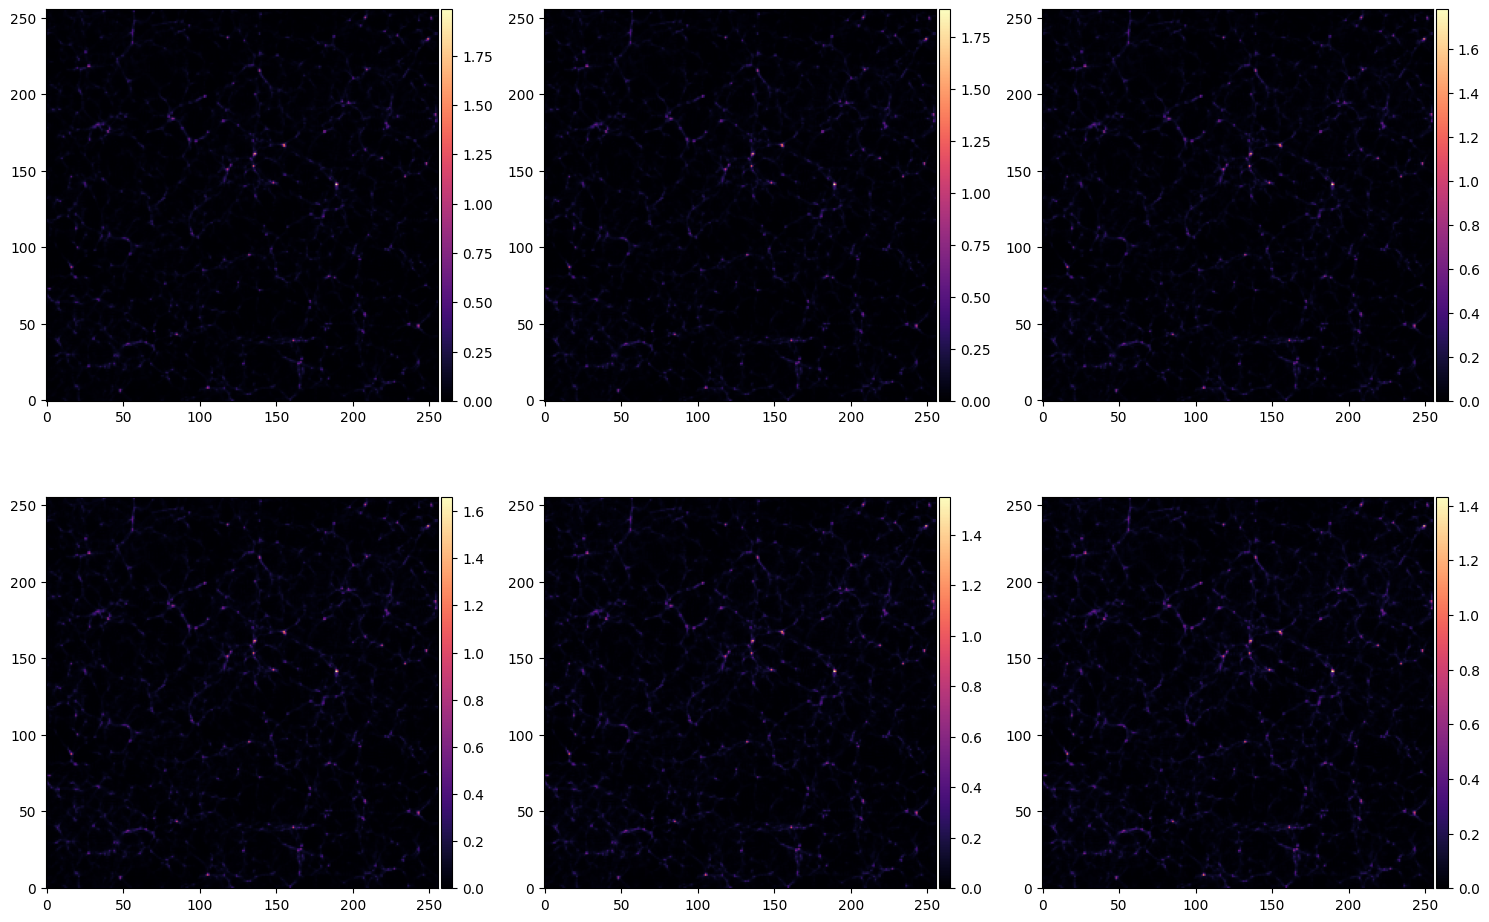

In [6]:
density_snapshots.paint_2d(center=density_snapshots.scale_factor).show()

/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int64 to dtype=int32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


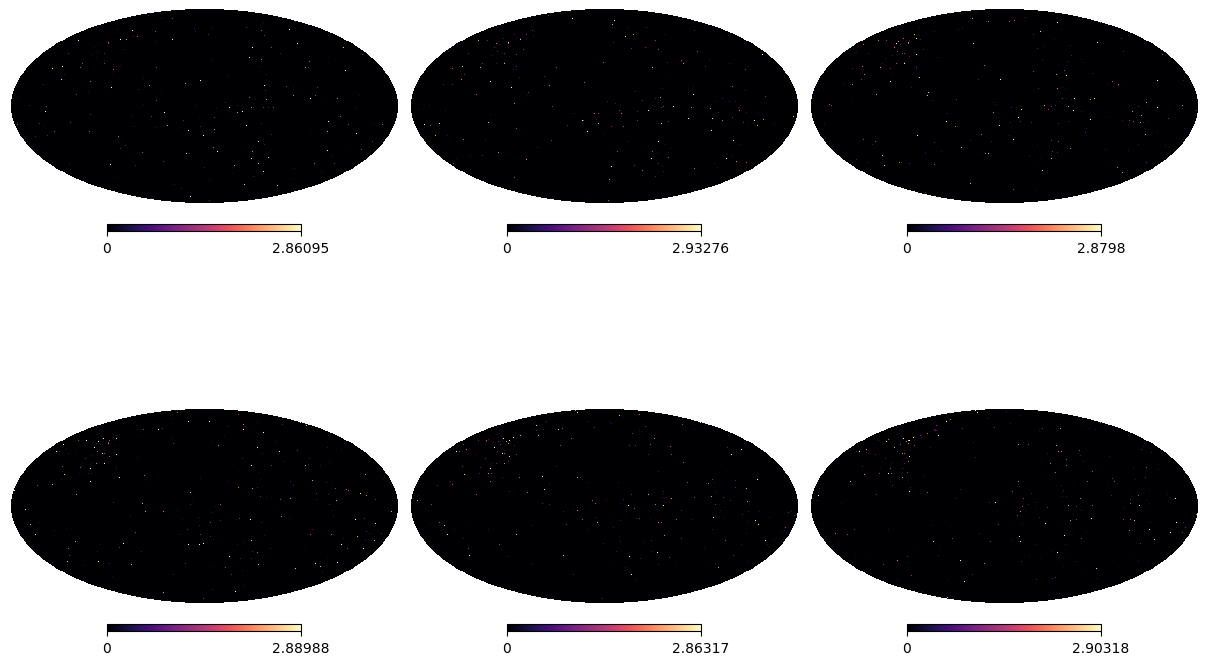

In [7]:
density_snapshots.paint_spherical(center=density_snapshots.scale_factor).show()

## Post-hoc Painting to Flat Geometry

Take the saved 3D density fields and project them to flat-sky 2D maps. We need to:
1. Extract each density field from the stacked snapshots
2. Convert to ParticleField for projection operations
3. Paint to flat 2D projection
4. Stack the results

In [8]:
# We'll need to convert DensityField to ParticleField for painting
# This is a simplified approach - in practice you'd work with the displacement fields
print("Note: For post-hoc painting, we would typically save displacement fields (geometry=None)")
print("and then use ParticleField.paint_2d() on each snapshot.")
print(f"Density snapshots contain {density_snapshots.shape[0]} shells.")

Note: For post-hoc painting, we would typically save displacement fields (geometry=None)
and then use ParticleField.paint_2d() on each snapshot.
Density snapshots contain 6 shells.


## Memory-Efficient: On-the-fly Flat Painting

Instead of saving all 3D fields, compute flat-sky projections during integration. This is memory-efficient.

In [ ]:
# Run N-body with geometry="flat" for on-the-fly painting
flat_lightcone = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=t1,
    dt0=dt0,
    geometry="flat",
)

print(f"Flat lightcone: {flat_lightcone}")
print(f"Array shape: {flat_lightcone.array.shape}")
print(f"Scale factor shape: {flat_lightcone.scale_factor.shape}")

flat_lightcone.paint_2d(center=flat_lightcone.scale_factor).show()

## Memory-Efficient: On-the-fly Spherical Painting

Compute HEALPix projections during integration for maximum memory efficiency.

In [ ]:
# Run N-body with geometry="spherical" for on-the-fly painting
spherical_lightcone = nbody(
    cosmo,
    dx_field,
    p_field,
    t1=t1,
    dt0=dt0,
    geometry="spherical",
)

print(f"Spherical lightcone: {spherical_lightcone}")
print(f"Array shape: {spherical_lightcone.array.shape}")
print(f"Scale factor shape: {spherical_lightcone.scale_factor.shape}")

spherical_lightcone.paint_spherical(center=spherical_lightcone.scale_factor).show()

## Memory Trade-off Summary

The `geometry` parameter offers a memory-flexibility trade-off:

- **`geometry=None`**: Saves 3D density fields at each shell
  - Pros: Flexible - can paint to any projection later
  - Cons: Memory-intensive (stores full 3D grids)
  - Use case: When you need multiple projections or post-processing

- **`geometry="flat"`**: Computes flat-sky projections on-the-fly
  - Pros: Memory-efficient (only stores 2D maps)
  - Cons: Fixed projection, cannot change later
  - Use case: When you only need flat-sky maps

- **`geometry="spherical"`**: Computes HEALPix projections on-the-fly
  - Pros: Memory-efficient, full-sky coverage
  - Cons: Fixed projection, cannot change later
  - Use case: When you only need all-sky maps